In [4]:
import json
import os

# --------- HÀM HỖ TRỢ ---------
def extract_final_answer(gt_steps):
    """Lấy đáp án cuối cùng từ ground truth (dòng 'Kết luận: ...')"""
    for step in reversed(gt_steps):
        if step.startswith("Kết luận:"):
            return step.strip()
    return None

import re

def extract_model_final_answer(output_text: str):
    if not output_text:
        return None

    text = output_text.strip()

    # 1) Tìm "Kết luận" (nếu có)
    match = re.search(r'kết luận[\s:.]*', text, flags=re.IGNORECASE)
    if match:
        idx = text.lower().rfind("kết luận")
        ans = text[idx + len("kết luận"):].strip(" :\n\t-")
        if ans:
            return ans

    # 2) Nếu có chia a), b), c), ... → lấy dòng cuối thực sự của từng phần
    parts = re.split(r'(?m)^\s*([a-zA-Z]\))', text)
    if len(parts) > 1:
        answers = []
        for i in range(1, len(parts), 2):
            label = parts[i].strip()
            body = parts[i+1].strip()
            # lấy dòng cuối thực sự có nội dung dạng số/biểu thức
            lines = [ln.strip() for ln in body.splitlines() if ln.strip()]
            answer_line = None
            for ln in reversed(lines):
                if re.search(r'[0-9=+\-*/]', ln):
                    answer_line = ln
                    break
            if answer_line is None and lines:
                answer_line = lines[-1]  # fallback lấy dòng cuối cùng
            if answer_line:
                answers.append(f"{label} {answer_line}")
        if answers:
            return "  ".join(answers)

    # 3) Không chia a/b/c → tìm dòng cuối có số/biểu thức
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        if re.search(r'[0-9=+\-*/]', ln):
            return ln

    # 4) Fallback cuối cùng → dòng cuối cùng bất kỳ
    return lines[-1] if lines else text




def build_combined(gt_path, model_paths, start_index_offset):
    """Ghép dữ liệu ground truth và outputs của nhiều model thành list"""
    # Đọc ground truth
    with open(gt_path, "r", encoding="utf-8") as f:
        gt_data = json.load(f)["problems"]

    # Lấy số câu theo model đầu tiên
    first_model = list(model_paths.values())[0]
    with open(first_model, "r", encoding="utf-8") as f:
        sample_model_data = json.load(f)

    start_index = len(gt_data) - len(sample_model_data)
    selected_gt = gt_data[start_index:]

    combined = []
    for i in range(len(sample_model_data)):
        gt_answer = extract_final_answer(selected_gt[i]["answer"]["steps"])

        outputs = {}
        for model_name, path in model_paths.items():
            with open(path, "r", encoding="utf-8") as f:
                model_data = json.load(f)
            outputs[model_name] = extract_model_final_answer(model_data[i]["output"])

        combined.append({
            "index": start_index_offset + i + 1,
            "question": selected_gt[i]["question"],
            "ground_truth": gt_answer,
            "model_outputs": outputs
        })
    return combined


# --------- CẤU HÌNH ---------
gt_paths = {
    "dai_so": "D:/RAG-Solve-Math/data/cleaned/test/dai_so.json",
    "giai_tich_1": "D:/RAG-Solve-Math/data/cleaned/test/giai_tich_1.json"
}

base_dir = "D:/RAG-Solve-Math/evaluate/Answer/"
models = ["qwen2b", "qwen2b-ft", "qwen4b", "qwen4b8m-ft", "qwen4b16m-ft"]

# --------- GỘP ---------
all_results = []
offset = 0

for subject_key, gt_path in gt_paths.items():
    model_paths = {
        m: os.path.join(base_dir, m, f"{subject_key}.json")
        for m in models
    }
    # Giữ lại file nào thực sự tồn tại
    model_paths = {k: v for k, v in model_paths.items() if os.path.exists(v)}

    if not model_paths:   # <-- fix thêm
        print(f"⚠️ Bỏ qua {gt_path} vì không tìm thấy file model nào")
        continue

    part_results = build_combined(gt_path, model_paths, start_index_offset=offset)
    all_results.extend(part_results)
    offset += len(part_results)

# --------- XUẤT RA FILE ---------
out_path = "comparison_200.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

print(f"✅ Đã tạo file gộp 200 câu cho tất cả model: {out_path}")


✅ Đã tạo file gộp 200 câu cho tất cả model: comparison_200.json


In [5]:
import json

with open("D:/RAG-Solve-Math/evaluate/Answer/qwen4b/dai_so.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("Tổng số câu:", len(data))
print("1 mẫu:", data[0])


Tổng số câu: 100
1 mẫu: {'index': 1, 'input': 'Cho $S, T: V \\rightarrow V$ là hai toán tử tuyến tính. a) Chứng minh rằng nếu $S, T$ chéo hóa được và giao hoán ($ST=TS$), thì chúng chéo hóa được đồng thời (tồn tại một cơ sở gồm các vector riêng chung cho cả $S$ và $T$). b) Cho $A = \\begin{pmatrix} 1 & 1 & 0 \\\\ 1 & 1 & 0 \\\\ 0 & 0 & 2 \\end{pmatrix}$ và $B = \\begin{pmatrix} 0 & 0 & 0 \\\\ 0 & 0 & 0 \\\\ 0 & 0 & 3 \\end{pmatrix}$. Kiểm tra $AB=BA$ và tìm một cơ sở chéo hóa đồng thời cho chúng.', 'output': '1. Phân tích bài toán:\n\n- Phần a): Cần chứng minh rằng nếu hai toán tử tuyến tính $S, T: V \\to V$ chéo hóa được và giao hoán ($ST = TS$), thì tồn tại một cơ sở chung gồm các vector riêng của cả hai toán tử.  \n- Phần b): Cho hai ma trận $A$ và $B$, kiểm tra xem chúng có giao hoán ($AB = BA$) hay không, và nếu có, tìm một cơ sở chéo hóa đồng thời.\n\n---\n\n2. Giải các bước chi tiết kèm công thức:\n\n**a) Chứng minh: Nếu $S, T$ chéo hóa được và $ST = TS$, thì chúng chéo hóa đồng

In [6]:
import os

base_dir = "D:/RAG-Solve-Math/evaluate/Answer"
models = ["qwen2b", "qwen2b-ft", "qwen4b", "qwen4b16m-ft"]

for m in models:
    model_dir = os.path.join(base_dir, m)
    if os.path.exists(model_dir):
        print(f"\n📂 Model {m}:")
        for f in os.listdir(model_dir):
            if f.endswith(".json"):
                print(" -", f)
    else:
        print(f"❌ Không tìm thấy folder cho model {m}")



📂 Model qwen2b:
 - dai_so_ly_thuyet.json
 - giai_tich_1_ly_thuyet.json

📂 Model qwen2b-ft:
 - dai_so.json
 - giai_tich_1.json

📂 Model qwen4b:
 - dai_so.json
 - dai_so_ly_thuyet.json
 - giai_tich_1.json
 - giai_tich_1_ly_thuyet.json

📂 Model qwen4b16m-ft:
 - dai_so_ly_thuyet.json
 - giai_tich_1_ly_thuyet.json


In [8]:
import json
import os
import pandas as pd
from sentence_transformers import SentenceTransformer, util

# ===== 1. Load SBERT =====
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

def semantic_score(gt_text, model_text):
    if not gt_text or not model_text:
        return 0.0
    emb1 = model.encode(gt_text, convert_to_tensor=True)
    emb2 = model.encode(model_text, convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).item()

# ===== 2. Lấy toàn bộ ground truth & output =====
def extract_full_gt(steps):
    return " ".join(steps).strip() if steps else ""

def extract_full_model(entry):
    return entry.get("output", "").strip()

# ===== 3. Mapping =====
gt_paths = {
    "baitap": {
        "dai_so": "D:/RAG-Solve-Math/data/cleaned/test/dai_so.json",
        "giai_tich": "D:/RAG-Solve-Math/data/cleaned/test/giai_tich_1.json"
    },
    "lythuyet": {
        "dai_so": "D:/RAG-Solve-Math/data/cleaned/test/dai_so_ly_thuyet.json",
        "giai_tich": "D:/RAG-Solve-Math/data/cleaned/test/giai_tich_1_ly_thuyet.json"
    }
}

file_mapping = {
    "baitap": {
        "dai_so": "dai_so.json",
        "giai_tich": "giai_tich_1.json"
    },
    "lythuyet": {
        "dai_so": "dai_so_ly_thuyet.json",
        "giai_tich": "giai_tich_1_ly_thuyet.json"
    }
}

base_dir = "D:/RAG-Solve-Math/evaluate/Answer/"
models = ["qwen2b", "qwen2b-ft", "qwen4b", "qwen4b8m-ft", "qwen4b16m-ft"]

# ===== 4. Hàm đánh giá =====
def evaluate_models(eval_type="baitap"):
    results = []
    for model_name in models:
        all_scores = []

        for subject_key, gt_path in gt_paths[eval_type].items():
            with open(gt_path, "r", encoding="utf-8") as f:
                gt_data = json.load(f)["problems"]

            model_file = os.path.join(base_dir, model_name, file_mapping[eval_type][subject_key])
            if not os.path.exists(model_file):
                continue

            with open(model_file, "r", encoding="utf-8") as f:
                model_data = json.load(f)

            # bài tập: lấy 100 câu cuối, lý thuyết: lấy hết
            if eval_type == "baitap":
                start_index = len(gt_data) - len(model_data)
                selected_gt = gt_data[start_index:]
            else:
                selected_gt = gt_data[:len(model_data)]

            # so sánh từng câu
            for i in range(len(model_data)):
                gt_ans = extract_full_gt(selected_gt[i]["answer"]["steps"])
                mo_ans = extract_full_model(model_data[i])
                score = semantic_score(gt_ans, mo_ans)
                all_scores.append(score)

        if all_scores:  # tránh rỗng
            avg_score = sum(all_scores) / len(all_scores)
            pct_good = sum(1 for s in all_scores if s >= 0.8) / len(all_scores)
            results.append({
                "model": model_name,
                "avg_similarity": avg_score,
                "%_good(>=0.8)": pct_good,
                "total_questions": len(all_scores)
            })

    return pd.DataFrame(results)

# ===== 5. Chạy =====
df_baitap = evaluate_models("baitap")
df_lythuyet = evaluate_models("lythuyet")

print("\n--- Kết quả Bài tập ---")
print(df_baitap)
print("\n--- Kết quả Lý thuyết ---")
print(df_lythuyet)

df_baitap.to_csv("semantic_eval_baitap.csv", index=False, encoding="utf-8-sig")
df_lythuyet.to_csv("semantic_eval_lythuyet.csv", index=False, encoding="utf-8-sig")
print("✅ Xuất CSV thành công")


c:\Users\LOQ\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\LOQ\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



--- Kết quả Bài tập ---
         model  avg_similarity  %_good(>=0.8)  total_questions
0    qwen2b-ft        0.870661           0.85              200
1       qwen4b        0.790367           0.49              200
2  qwen4b8m-ft        0.883850           0.86              200

--- Kết quả Lý thuyết ---
          model  avg_similarity  %_good(>=0.8)  total_questions
0        qwen2b        0.717779       0.291866              209
1        qwen4b        0.760519       0.430622              209
2  qwen4b16m-ft        0.790276       0.516746              209
✅ Xuất CSV thành công


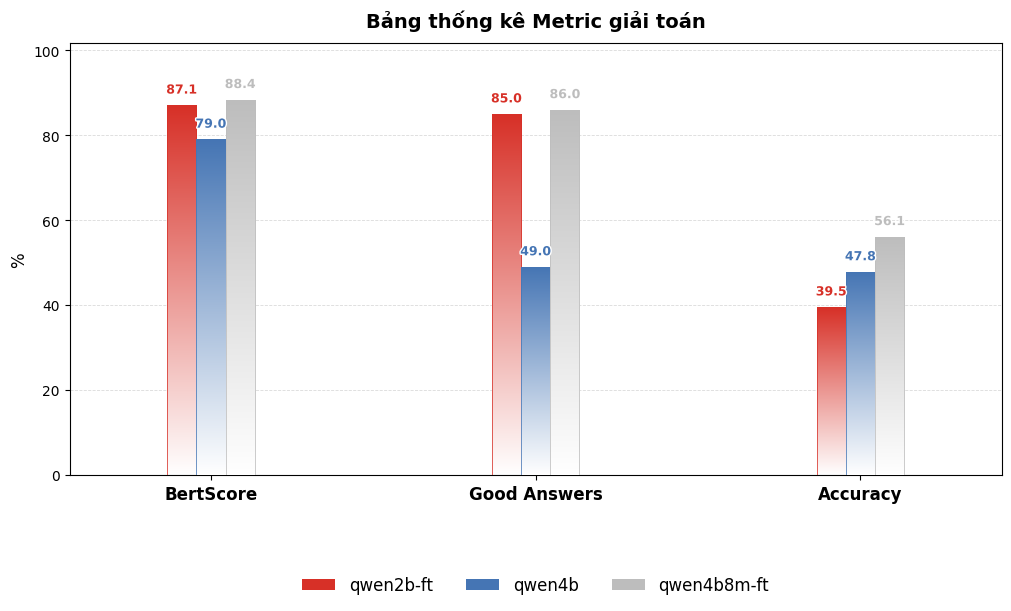

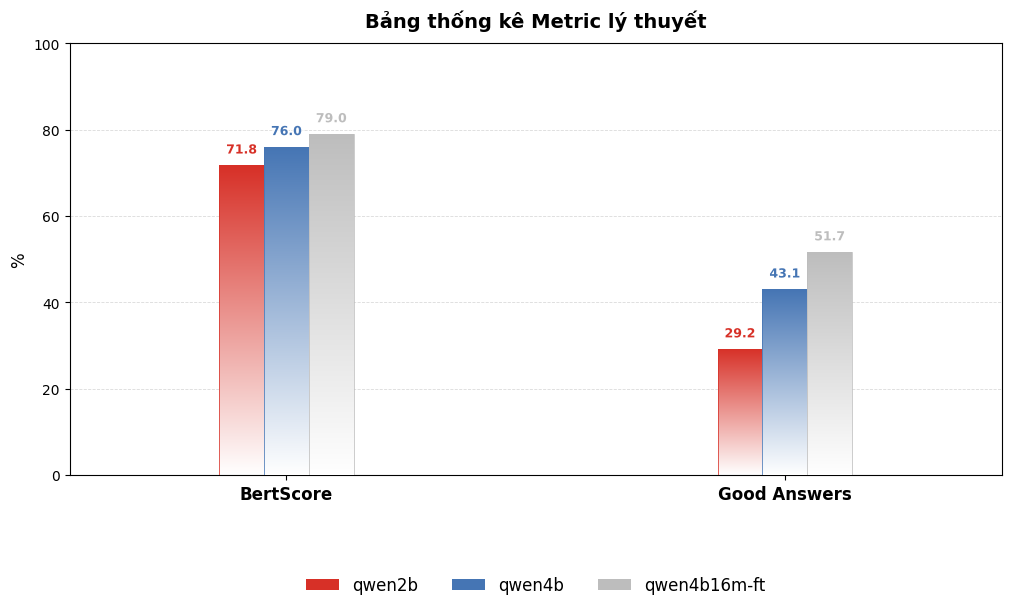

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
import matplotlib.patheffects as pe

# ---- files ----
PATH_BAITAP = "semantic_eval_baitap.csv"
PATH_LYTHUYET = "semantic_eval_lythuyet.csv"
PATH_SUMMARY = "D:/RAG-Solve-Math/grading_summary_manual.csv"

# ---- load ----
df_baitap = pd.read_csv(PATH_BAITAP)
df_lythuyet = pd.read_csv(PATH_LYTHUYET)
df_summary = pd.read_csv(PATH_SUMMARY)

# ---- rename summary percent -> Accuracy ----
if "percent" in df_summary.columns:
    df_summary = df_summary.rename(columns={"percent": "Accuracy"})

# ---- rename metrics ----
rename_map = {
    "avg_similarity": "BertScore",
    "%_good(>=0.8)": "Good Answers"
}
df_baitap = df_baitap.rename(columns=rename_map)
df_lythuyet = df_lythuyet.rename(columns=rename_map)

# ---- merge Accuracy into baitap ----
df_baitap = pd.merge(df_baitap, df_summary[["model", "Accuracy"]],
                     on="model", how="left")

# ---- normalize to percent ----
def normalize_percent(df):
    cols = [c for c in df.columns if c not in ("model", "total_questions")]
    for c in cols:
        arr = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
        if np.nanmax(np.nan_to_num(arr)) <= 1.01:
            df[c] = np.round(arr * 100.0, 2)
        else:
            df[c] = np.round(arr, 2)
    return df

df_baitap = normalize_percent(df_baitap)
df_lythuyet = normalize_percent(df_lythuyet)

# ---- plotting function ----
def plot_grouped_bar_gradient(df, title, filename,
                              base_colors=None, figsize=(10,6),
                              bar_narrow=0.09, fontsize_vals=9, legend_font=12):
    metrics = [c for c in df.columns if c not in ("model", "total_questions")]
    if len(metrics) == 0:
        raise ValueError("No metrics to plot.")
    models = df["model"].tolist()
    data = np.vstack([df.loc[df["model"] == m, metrics].values.flatten() for m in models])
    n_models, n_metrics = data.shape

    if base_colors is None:
        base_colors = ["#d73027", "#4575b4", "#bdbdbd", "#fdae61", "#8c6bb1"]
    colors = [base_colors[i % len(base_colors)] for i in range(n_models)]

    x = np.arange(n_metrics)
    bar_width = bar_narrow
    offsets = (np.arange(n_models) - (n_models-1)/2.0) * bar_width

    # ymax safe
    max_val = np.nanmax(data)
    y_max = max(100, float(max_val) * 1.15)

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    ax.set_facecolor("#ffffff")
    ax.grid(axis='y', linestyle="--", linewidth=0.6, alpha=0.45)
    ax.set_axisbelow(True)

    for i in range(n_models):
        vals = data[i, :]
        for j, v in enumerate(vals):
            xpos = x[j] + offsets[i]
            left = xpos - bar_width/2
            if v > 0:
                n = 256
                grad = np.linspace(0, 1, n).reshape(n, 1)
                cmap = mpl.colors.LinearSegmentedColormap.from_list("tmp", ["#ffffff", colors[i]])
                img = cmap(grad)
                im = ax.imshow(img, aspect='auto',
                               extent=(left, left + bar_width, 0, v),
                               origin='lower', interpolation='bicubic', zorder=2+i)
                rect = mpatches.Rectangle((left, 0), bar_width, v, transform=ax.transData)
                im.set_clip_path(rect)
                ax.add_patch(mpatches.Rectangle((left, 0), bar_width, v,
                                               fill=False, linewidth=0.6,
                                               edgecolor=mpl.colors.to_rgba(colors[i], 0.9),
                                               zorder=3+i))
            # label
            y_label = v + y_max*0.02
            if y_label > y_max:
                y_label = y_max - y_max*0.02
            ax.text(xpos, y_label, f"{v:.1f}",
                    ha="center", va="bottom", fontsize=fontsize_vals,
                    fontweight="bold", color=colors[i], zorder=10,
                    path_effects=[pe.Stroke(linewidth=2, foreground="white"), pe.Normal()])

    ax.set_xticks(x)
    # fix tràn cột ngoài cùng, giảm margin cho gần nhau
    margin = bar_width * (n_models/2 )+ 0.3
    ax.set_xlim(x.min() - margin, x.max() + margin)

    ax.set_xticklabels(metrics, fontsize=12, fontweight="bold")

    ax.set_ylim(0, y_max)
    ax.set_ylabel("%", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.yaxis.set_major_locator(MultipleLocator(20))

    handles = [mpatches.Patch(facecolor=colors[i], edgecolor="none", label=models[i]) for i in range(n_models)]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.2),
              ncol=min(5, n_models), frameon=False, fontsize=legend_font)

    fig.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0.2)
    plt.show()
    plt.close(fig)

# ---- plots ----
plot_grouped_bar_gradient(df_baitap, "Bảng thống kê Metric giải toán", "baitap_final.png")

plot_grouped_bar_gradient(df_lythuyet, "Bảng thống kê Metric lý thuyết", "lythuyet_final.png")
